In [56]:
conda install funcy

Channels:
 - pytorch
 - defaults
 - https://mirrors.tuna.tsinghua.edu.cn/anaconda/pkgs/free
 - conda-forge
 - https://repo.anaconda.com/pkgs/main
 - https://repo.anaconda.com/pkgs/r
 - https://repo.anaconda.com/pkgs/msys2
Platform: win-64
Solving environment: ...working... done

## Package Plan ##

  environment location: D:\Anaconda3\install\envs\data_view

  added / updated specs:
    - funcy


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    funcy-2.0                  |     pyhd8ed1ab_1          30 KB  conda-forge
    ------------------------------------------------------------
                                           Total:          30 KB

The following NEW packages will be INSTALLED:

  funcy              conda-forge/noarch::funcy-2.0-pyhd8ed1ab_1 

The following packages will be SUPERSEDED by a higher-priority channel:

  certifi            conda-forge/noarch::certifi-2025.1.31~ -

In [94]:
import pandas as pd
from pyecharts.charts import Pie
from pyecharts import options as opts

# 常量配置
PROVINCES = ['北京', '上海', '黑龙江', '吉林', '辽宁', '内蒙古', '新疆', '西藏', '青海', '四川', '云南', '陕西', '重庆',
             '贵州', '广西', '海南', '澳门', '湖南', '江西', '福建', '安徽', '浙江', '江苏', '宁夏', '山西', '河北', '天津']
NUM = [1, 1, 1, 17, 9, 22, 23, 42, 35, 7, 20, 21, 16, 24, 16, 21, 37, 12, 13, 14, 13, 7, 22, 8, 16, 13, 13]
COLOR_SERIES = [
    '#FAE927', '#E9E416', '#C9DA36', '#9ECB3C', '#6DBC49',
    '#37B44E', '#3DBA78', '#14ADCF', '#209AC9', '#1E91CA',
    '#2C6BA0', '#2B55A1', '#2D3D8E', '#44388E', '#6A368B',
    '#7D3990', '#A63F98', '#C31C88', '#D52178', '#D5225B',
    '#D02C2A', '#D44C2D', '#F57A34', '#FA8F2F', '#D99D21',
    '#CF7B25', '#CF7B25', '#CF7B25'
]
CHART_WIDTH = '1350px'
CHART_HEIGHT = '750px'
CHART_TITLE = '玫瑰图示例'
OUTPUT_FILE = '南丁格尔玫瑰图.html'

def create_data_frame(provinces, num):
    """创建并排序数据框"""
    df = pd.DataFrame({'provinces': provinces, 'num': num})
    df.sort_values(by='num', ascending=False, inplace=True)
    return df['provinces'].values.tolist(), df['num'].values.tolist()

def create_pie_chart(labels, data):
    """创建饼图"""
    pie = Pie(init_opts=opts.InitOpts(width=CHART_WIDTH, height=CHART_HEIGHT))
    pie.set_colors(COLOR_SERIES)
    pie.add(
        "",
        [list(z) for z in zip(labels, data)],
        radius=["30%", "135%"],
        center=["50%", "65%"],
        rosetype="area"
    )
    pie.set_global_opts(
        title_opts=opts.TitleOpts(title=CHART_TITLE),
        legend_opts=opts.LegendOpts(is_show=False),
        toolbox_opts=opts.ToolboxOpts()
    )
    pie.set_series_opts(
        label_opts=opts.LabelOpts(
            is_show=True,
            position="inside",
            font_size=12,
            formatter="{b}:{c}天",
            font_style="italic",
            font_weight="bold",
            font_family="Microsoft YaHei"
        )
    )
    return pie

def main():
    """主函数"""
    labels, data = create_data_frame(PROVINCES, NUM)
    pie_chart = create_pie_chart(labels, data)
    pie_chart.render(OUTPUT_FILE)
    print(f"请打开文件夹，查看{OUTPUT_FILE}")

if __name__ == '__main__':
    main()

请打开文件夹，查看南丁格尔玫瑰图.html


In [95]:
import pandas as pd
from pyecharts.charts import Pie
from pyecharts import options as opts

# 常量配置
DATA_FILE = '疫情各国确诊数据.csv'
COLOR_SERIES = [
    '#FAE927', '#E9E416', '#C9DA36', '#9ECB3C', '#6DBC49',
    '#37B44E', '#3DBA78', '#14ADCF', '#209AC9', '#1E91CA',
    '#2C6BA0', '#2B55A1', '#2D3D8E', '#44388E', '#6A368B',
    '#7D3990', '#A63F98', '#C31C88', '#D52178', '#D5225B',
    '#D02C2A', '#D44C2D', '#F57A34', '#FA8F2F', '#D99D21',
    '#CF7B25', '#CF7B25', '#CF7B25'
]
CHART_WIDTH = '1350px'
CHART_HEIGHT = '750px'
CHART_TITLE = '玫瑰图示例'
OUTPUT_FILE = '南丁格尔玫瑰图2.html'

def load_data(file_path):
    """加载数据并处理"""
    df = pd.read_csv(file_path)
    head_df = df.head(30).iloc[1:]  # 取前30个，去掉美国
    head_df.sort_values(by='确诊病例', ascending=False, inplace=True)  # 降序排序
    return head_df['国家/地区'].values.tolist(), head_df['确诊病例'].values.tolist()

def create_pie_chart(labels, data):
    """创建饼图"""
    pie = Pie(init_opts=opts.InitOpts(width=CHART_WIDTH, height=CHART_HEIGHT))
    pie.set_colors(COLOR_SERIES)
    pie.add(
        "",
        [list(z) for z in zip(labels, data)],
        radius=["30%", "135%"],
        center=["50%", "65%"],
        rosetype="area"
    )
    pie.set_global_opts(
        title_opts=opts.TitleOpts(title=CHART_TITLE),
        legend_opts=opts.LegendOpts(is_show=False),
        toolbox_opts=opts.ToolboxOpts()
    )
    pie.set_series_opts(
        label_opts=opts.LabelOpts(
            is_show=True,
            position="inside",
            font_size=12,
            formatter="{b}:{c}",
            font_style="italic",
            font_weight="bold",
            font_family="Microsoft YaHei"
        )
    )
    return pie

def main():
    """主函数"""
    labels, data = load_data(DATA_FILE)
    pie_chart = create_pie_chart(labels, data)
    pie_chart.render(OUTPUT_FILE)
    print(f"请打开文件夹，查看{OUTPUT_FILE}")

if __name__ == '__main__':
    main()

请打开文件夹，查看南丁格尔玫瑰图2.html


In [62]:
conda install openpyxl

Channels:
 - pytorch
 - defaults
 - https://mirrors.tuna.tsinghua.edu.cn/anaconda/pkgs/free
 - conda-forge
 - https://repo.anaconda.com/pkgs/main
 - https://repo.anaconda.com/pkgs/r
 - https://repo.anaconda.com/pkgs/msys2
Platform: win-64
Solving environment: ...working... done

## Package Plan ##

  environment location: D:\Anaconda3\install\envs\data_view

  added / updated specs:
    - openpyxl


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    et_xmlfile-1.1.0           |   py39haa95532_0          10 KB  defaults
    openpyxl-3.1.5             |   py39h827c3e9_1         567 KB  defaults
    ------------------------------------------------------------
                                           Total:         577 KB

The following NEW packages will be INSTALLED:

  et_xmlfile         anaconda/pkgs/main/win-64::et_xmlfile-1.1.0-py39haa95532_0 
  openpyxl           anaconda/pkgs/main/win-

Retrying (Retry(total=2, connect=None, read=None, redirect=None, status=None)) after connection broken by 'ProxyError('Cannot connect to proxy.', RemoteDisconnected('Remote end closed connection without response'))': /pkgs/msys2/noarch/repodata.json.zst



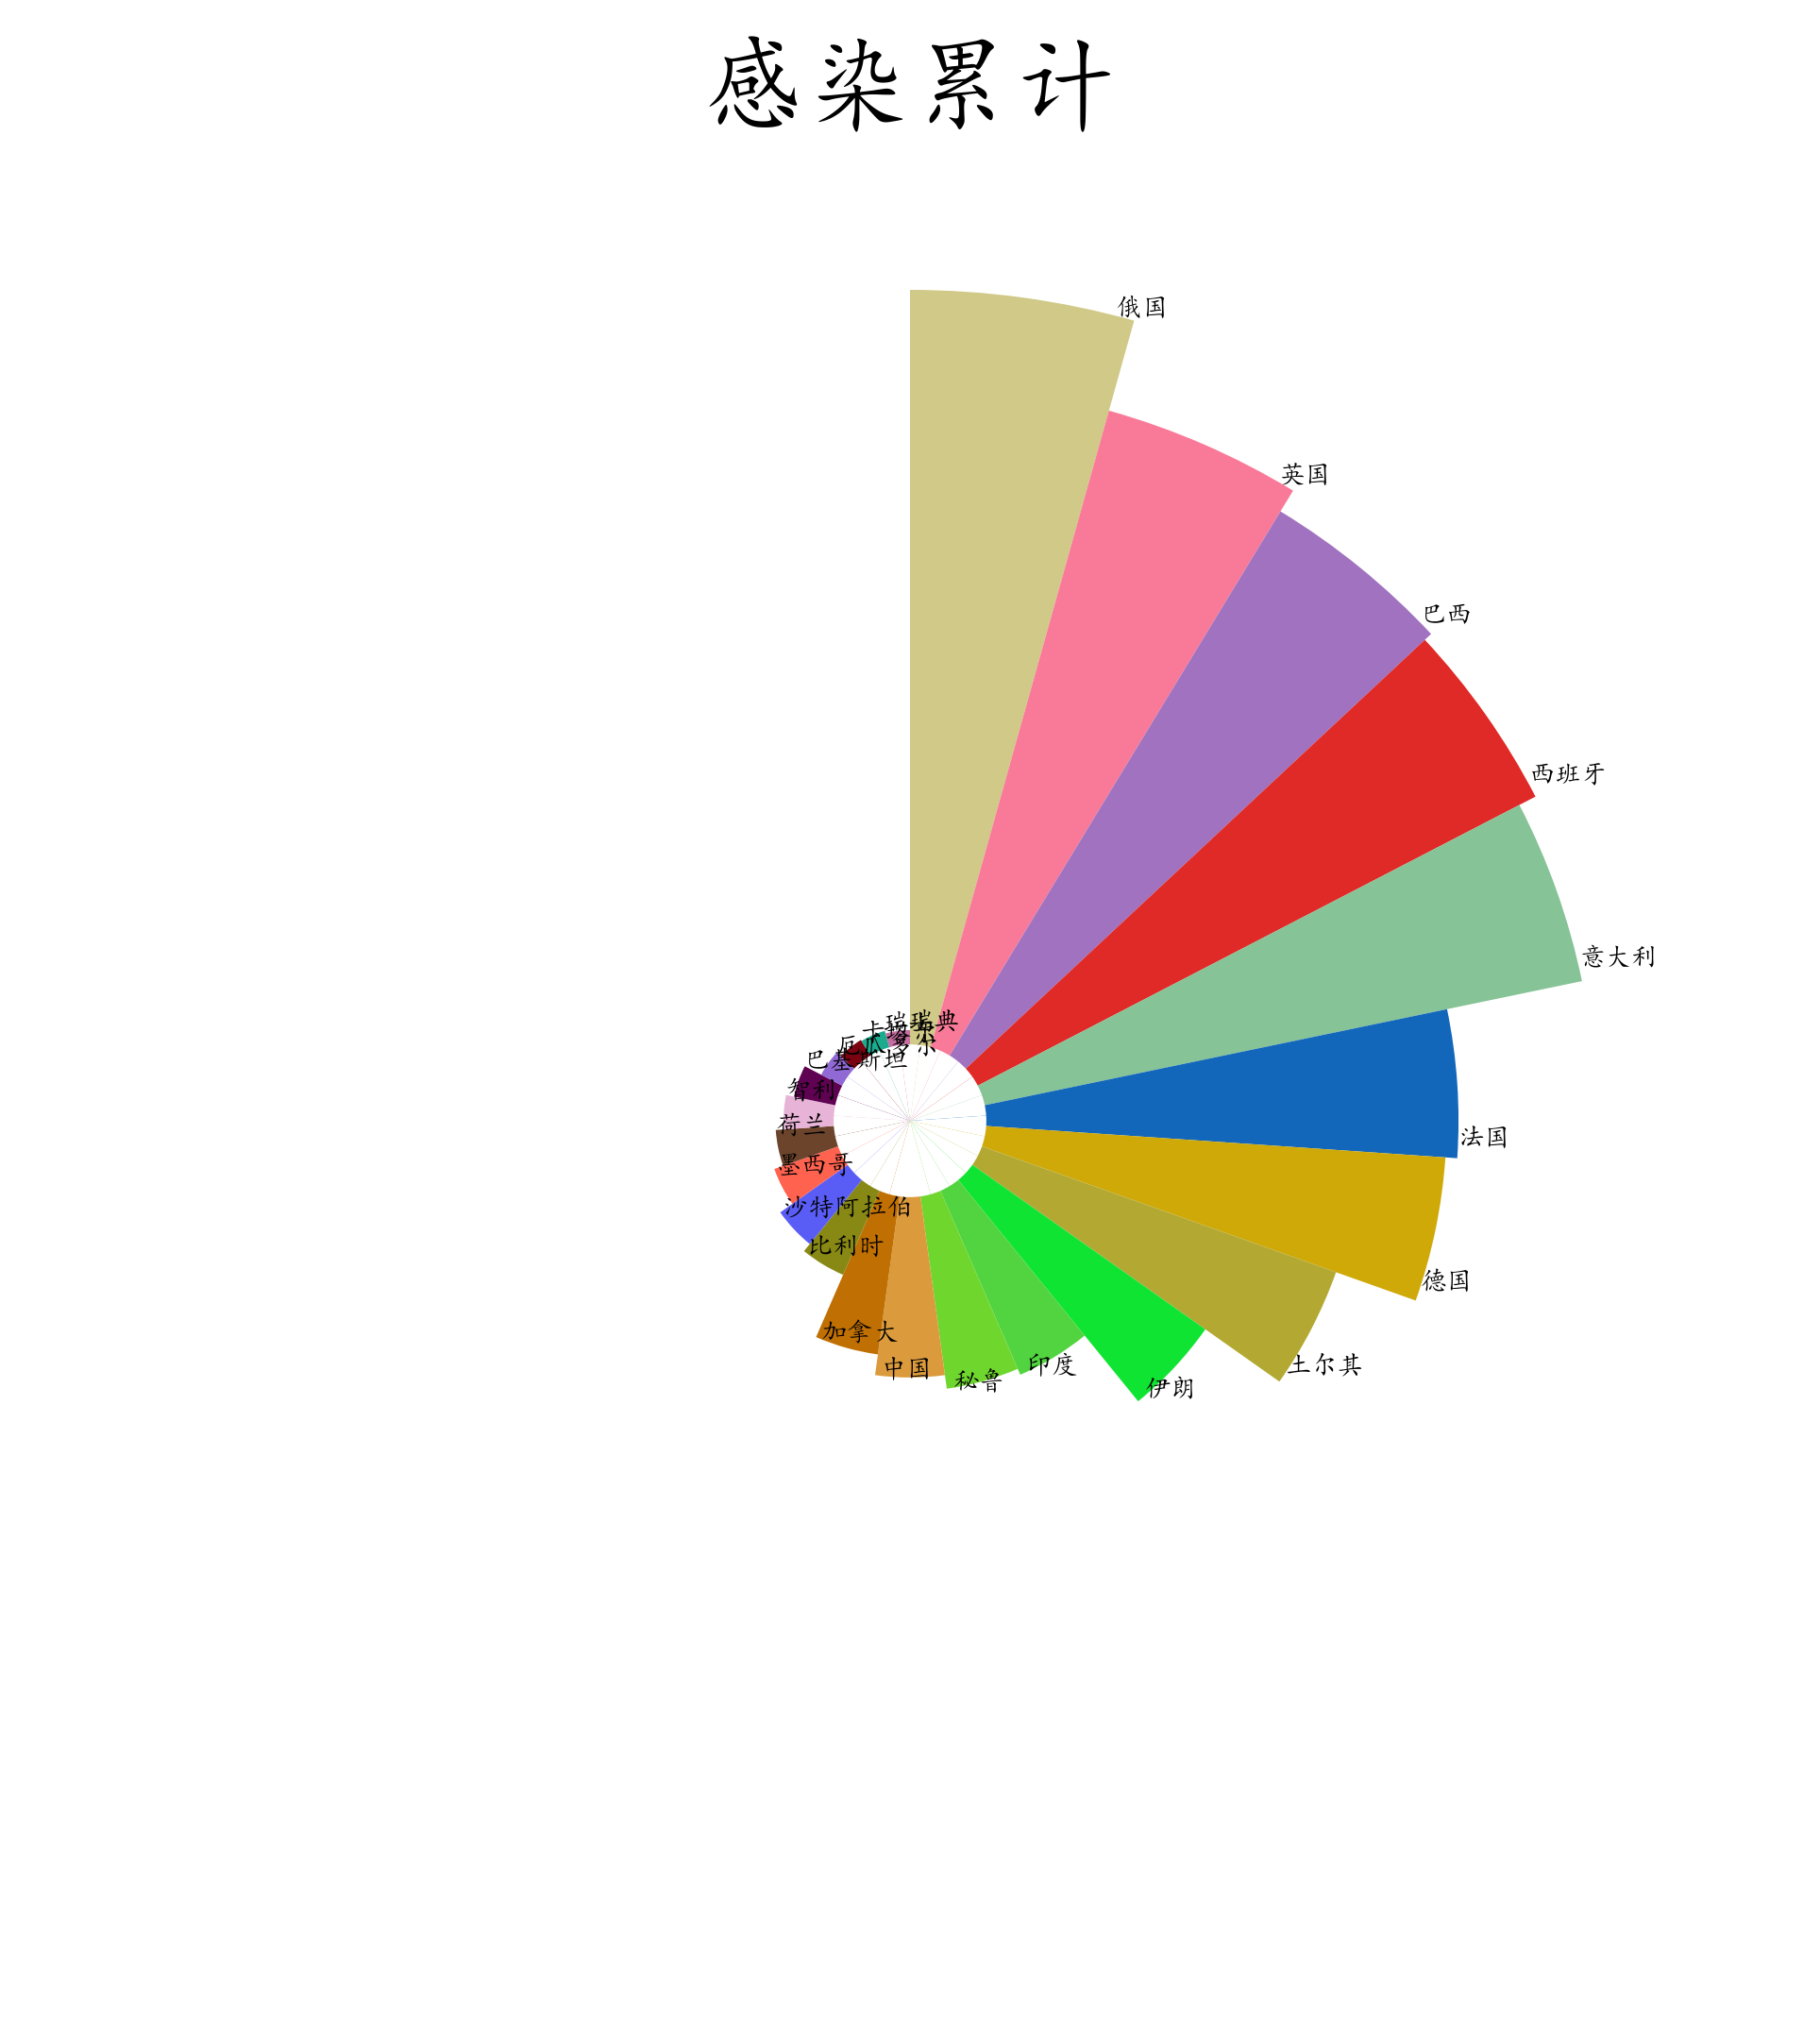

In [137]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# 常量配置
FONT_PATH = r'../simkai.ttf'  # 字体路径
DATA_FILE = '疫情各国确诊数据.csv'
OUTPUT_IMAGE = '南丁格尔图.png'
CHART_TITLE = '感染累计'
FIGURE_SIZE = (10, 6)
DPI = 400

# 设置字体
def setup_font(font_path):
    """设置中文字体"""
    font_prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = font_prop.get_name()
    plt.rcParams['axes.unicode_minus'] = False

# 加载数据
def load_data(file_path):
    """加载数据并处理"""
    df = pd.read_csv(file_path)
    head_df = df.head(24).iloc[1:]  # 取前24个，去掉美国
    head_df.sort_values(by='确诊病例', ascending=False, inplace=True)  # 降序排序
    return head_df['国家/地区'].values.tolist(), head_df['确诊病例'].values.tolist()

# 绘制极坐标图
def draw_polar_chart(labels, data):
    """绘制极坐标图"""
    fig = plt.figure(figsize=FIGURE_SIZE, dpi=DPI)
    ax = plt.axes(polar=True)
    ax.set_theta_zero_location("N")  # 极坐标 0° 方向为 N
    ax.set_theta_direction(-1)  # 顺时针为极坐标正方向
    theta = np.linspace(0, np.pi * 2, len(data), endpoint=False)  # 等分极坐标系

    # 绘制柱状图
    ax.bar(
        x=theta,
        height=data,
        width=np.pi / len(data) * 2,
        color=np.random.random((len(data), 3)),
        align="edge"
    )

    # 绘制中心空白
    ax.bar(
        x=theta,
        height=25000,
        width=np.pi / len(data) * 2,
        color='white'
    )

    # 设置标题
    ax.set_title(CHART_TITLE, fontdict={'fontsize': 20})

    # 标注文本
    for angle, height, text in zip(theta, data, labels):
        ax.text(angle + 0.25, height + 120, str(text), fontsize=5)

    plt.axis("off")
    plt.savefig(OUTPUT_IMAGE, dpi=400)
    plt.show()

def main():
    """主函数"""
    setup_font(FONT_PATH)
    labels, data = load_data(DATA_FILE)
    draw_polar_chart(labels, data)

if __name__ == '__main__':
    main()

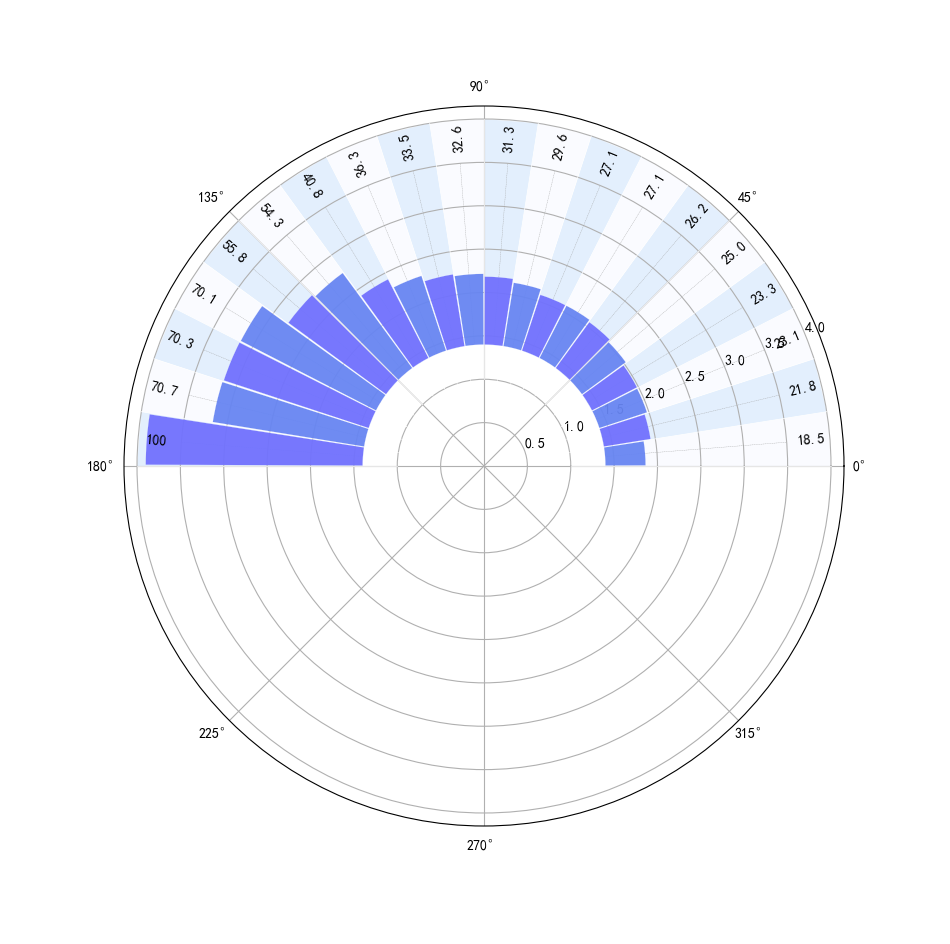

In [130]:
import numpy as np
import matplotlib.pyplot as plt
import funcy
import warnings
import matplotlib.font_manager as fm

# 忽略警告
warnings.filterwarnings('ignore')

# 设置字体路径
FONT_PATH = r'../simkai.ttf'
font_prop = fm.FontProperties(fname=FONT_PATH)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 示例数据
MAJORS = ['营销', '金融', '心理学', '新闻学', '电视', '日语', '汉语言', '物理', '机械', '文学', '生物', '计算机', '化学', '数学', '设计', '英语', '会计', '教育', '工程', '医学']
DATAS = [18.7, 21.6, 22.9, 23.5, 24.8, 26.2, 27.1, 27.1, 29.6, 31.3, 32.6, 33.5, 36.3, 40.8, 54.3, 55.8, 70.1, 70.3, 70.7, 100]
MAJORS = [
    '营销', '金融', '心理学', '新闻学', '电视', '日语', '汉语言', '物理', '机械', '文学', 
    '生物', '计算机', '化学', '数学', '设计', '英语', '会计', '教育', '工程', '医学', 
    '法学', '历史学', '地理学', '环境科学', '艺术'
]
DATAS = [
    18.5, 21.8, 23.1, 23.3, 25.0, 26.2, 27.1, 27.1, 29.6, 31.3, 
    32.6, 33.5, 36.3, 40.8, 54.3, 55.8, 70.1, 70.3, 70.7, 100, 
    28.5, 19.4, 22.3, 35.7, 48.9
]
# 常量配置
FIGURE_SIZE = (12, 12)
DPI = 100
AXES_POSITION = [0.22, 0.2, 0.6, 0.6]
THETA_GROUP = np.linspace(0, 1, 21) * np.pi
COLORS = ['#fafbff', '#e3effd']  # 扇形区域颜色
BAR_COLORS = ['#6785f2', '#7171fe']  # 柱状图颜色
DASHED_LINE_COLOR = '#9fa0a0'
WHITE_BOUNDARY_COLOR = 'w'

def setup_polar_plot():
    """设置极坐标图的基本配置"""
    fig, ax = plt.subplots(figsize=FIGURE_SIZE, dpi=DPI)
    ax1 = fig.add_axes(AXES_POSITION, polar=True)
    ax.get_yaxis().set_visible(False)
    ax.get_xaxis().set_visible(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    return fig, ax1

def draw_sector_regions(ax1):
    """绘制扇形区域"""
    for idx, (start, end) in enumerate(funcy.pairwise(THETA_GROUP)):
        ax1.fill_between([start, end], 1.4, 4, facecolor=COLORS[idx % 2])

def draw_dashed_lines(ax1):
    """绘制虚线"""
    for start, end in funcy.pairwise(THETA_GROUP):
        theta = (start + end) / 2
        ax1.plot([theta, theta], [1.4, 3.5], linestyle='dashed', color=DASHED_LINE_COLOR, linewidth=0.25)

def draw_bars(ax1):
    """绘制柱状图"""
    for idx, (start, end) in enumerate(funcy.pairwise(THETA_GROUP)):
        theta = (start + end) / 2
        ax1.bar(theta, 0.025 * DATAS[idx], width=np.pi / 21, bottom=1.4,
                facecolor=BAR_COLORS[idx % 2], edgecolor='white', linewidth=0.1, alpha=0.95, zorder=9)

def draw_white_boundaries(ax1):
    """绘制扇形区域白色边界"""
    for theta in THETA_GROUP:
        ax1.plot([theta, theta], [1, 4], color=WHITE_BOUNDARY_COLOR, linewidth=0.5)

def annotate_majors_and_datas(ax1):
    """标注专业名称和数据"""
    for idx, (start, end) in enumerate(funcy.pairwise(THETA_GROUP)):
        angle = ((start + end) * 0.5 / np.pi) * 180 - (0 if idx < (len(MAJORS) / 2) else 180)
        # 标注专业名称
        ax1.annotate(MAJORS[idx], xy=[(start + end) / 2, 4.4], va='center', ha='center', zorder=10, rotation=angle, fontsize=10)
        # 标注数据
        ax1.annotate(DATAS[idx], xy=[(start + end) / 2, 3.79], va='center', ha='center', zorder=10, rotation=angle, fontsize=10)

def main():
    """主函数"""
    fig, ax1 = setup_polar_plot()
    draw_sector_regions(ax1)
    draw_dashed_lines(ax1)
    draw_bars(ax1)
    draw_white_boundaries(ax1)
    annotate_majors_and_datas(ax1)
    plt.show()

if __name__ == '__main__':
    main()